## Ratings & Popularity Analysis

Here we analyze the rating and popularity of the Blakan produced movies. The goal is to identify patterns in the films quality and the audio engagement across each country.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
# Load dataset
df = pd.read_csv('data/balkan_movies_master_clean.csv')

BALKAN_COUNTRIES = [
    'Romania', 'Greece', 'Yugoslavia', 'Serbia', 'Albania',
    'Bulgaria', 'Croatia', 'Slovenia', 'Bosnia and Herzegovina',
    'North Macedonia', 'Kosovo', 'Montenegro'
]

# We want to have single-country entires (no "France|Romania" for example)
movies = df[df['country'].isin(BALKAN_COUNTRIES)].copy()

print(f"Total Balkan movies (single-country): {len(movies)}")

Total Balkan movies (single-country): 4271


IMDb ratings reflect the critical and audioence reception of films. The chart below shows the average rating per country alongside the number of rated movies.

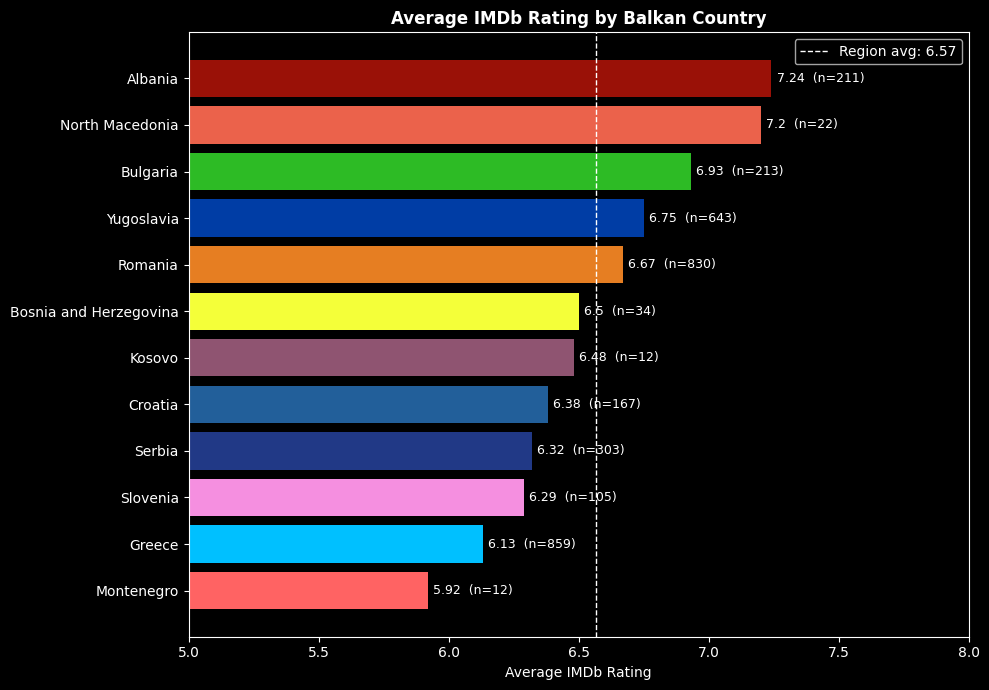

In [12]:
imdb_ratings = (
    movies[movies['imdb_rating'].notna()]
    .groupby('country')
    .agg(avg_imdb_rating=('imdb_rating', 'mean'), num_rated_movies=('imdb_rating', 'count'))
    .round(2)
    .sort_values('avg_imdb_rating', ascending=True)
    .reset_index()
)
#gave to each country their color, made like that so i can use it on the other cells
COUNTRY_COLORS = {
    'Albania':                 '#9a1107',
    'Bosnia and Herzegovina':  '#f4ff39',
    'Bulgaria':                '#2dbb25',
    'Croatia':                 '#225f9a',
    'Greece':                  '#00c0ff',
    'Kosovo':                  '#8f5471',
    'Montenegro':              '#ff6363',
    'North Macedonia':         '#eb624b',
    'Romania':                 '#e67e22',
    'Serbia':                  '#213986',
    'Slovenia':                '#f58fe0',
    'Yugoslavia':              '#003DA5',
}

colors = [COUNTRY_COLORS.get(c, 'gray') for c in imdb_ratings['country']]

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(imdb_ratings['country'], imdb_ratings['avg_imdb_rating'], color=colors)
ax.axvline(x=imdb_ratings['avg_imdb_rating'].mean(), color='white', linestyle='--', linewidth=1, label=f"Region avg: {imdb_ratings['avg_imdb_rating'].mean():.2f}")
ax.set_xlim(5, 8)

for bar, val, n in zip(bars, imdb_ratings['avg_imdb_rating'], imdb_ratings['num_rated_movies']):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val}  (n={n})', va='center', fontsize=9)

ax.set_xlabel('Average IMDb Rating')
ax.set_title('Average IMDb Rating by Balkan Country', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('graphs/ratings_combined.png', dpi=150, bbox_inches='tight')
plt.show()

Popularity is measured by the total and avg number of IMDb votes a country's films receive. In general, vote vount is a proxy for international audience reach.

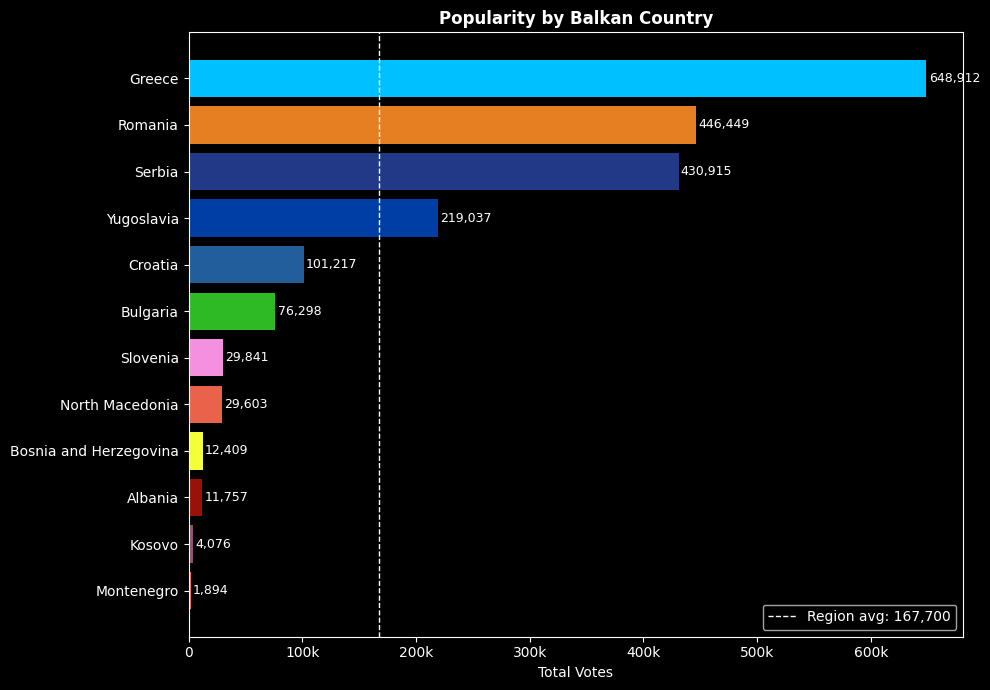

In [13]:
# IMDb votes for popularity by country
popularity = (
    movies[movies['imdb_votes'].notna()]
    .groupby('country')
    .agg(total_votes=('imdb_votes', 'sum'), avg_imdb_votes=('imdb_votes', 'mean'))
    .round(0)
    .sort_values('total_votes', ascending=True)
    .reset_index()
)

colors = [COUNTRY_COLORS.get(c, 'gray') for c in popularity['country']]

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(popularity['country'], popularity['total_votes'], color=colors)
ax.axvline(x=popularity['total_votes'].mean(), color='white', linestyle='--', linewidth=1, label=f"Region avg: {int(popularity['total_votes'].mean()):,}")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))

for bar, val in zip(bars, popularity['total_votes']):
    ax.text(val + 2000, bar.get_y() + bar.get_height()/2, f'{int(val):,}', va='center', fontsize=9)

ax.set_xlabel('Total Votes')
ax.set_title('Popularity by Balkan Country', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('graphs/popularity_combined.png', dpi=150, bbox_inches='tight')
plt.show()

Merged both metrics for a full picture of each country's film output.

In [14]:
# Combined ratings & popularity
summary = imdb_ratings.merge(popularity, on='country', how='outer')
summary

,country,avg_imdb_rating,num_rated_movies,total_votes,avg_imdb_votes
0,Albania,7.24,211,11757.0,56.0
1,Bosnia and Herzegovina,6.50,34,12409.0,365.0
2,Bulgaria,6.93,213,76298.0,358.0
3,Croatia,6.38,167,101217.0,606.0
4,Greece,6.13,859,648912.0,755.0
5,Kosovo,6.48,12,4076.0,340.0
6,Montenegro,5.92,12,1894.0,158.0
7,North Macedonia,7.20,22,29603.0,1346.0
8,Romania,6.67,830,446449.0,538.0
9,Serbia,6.32,303,430915.0,1422.0


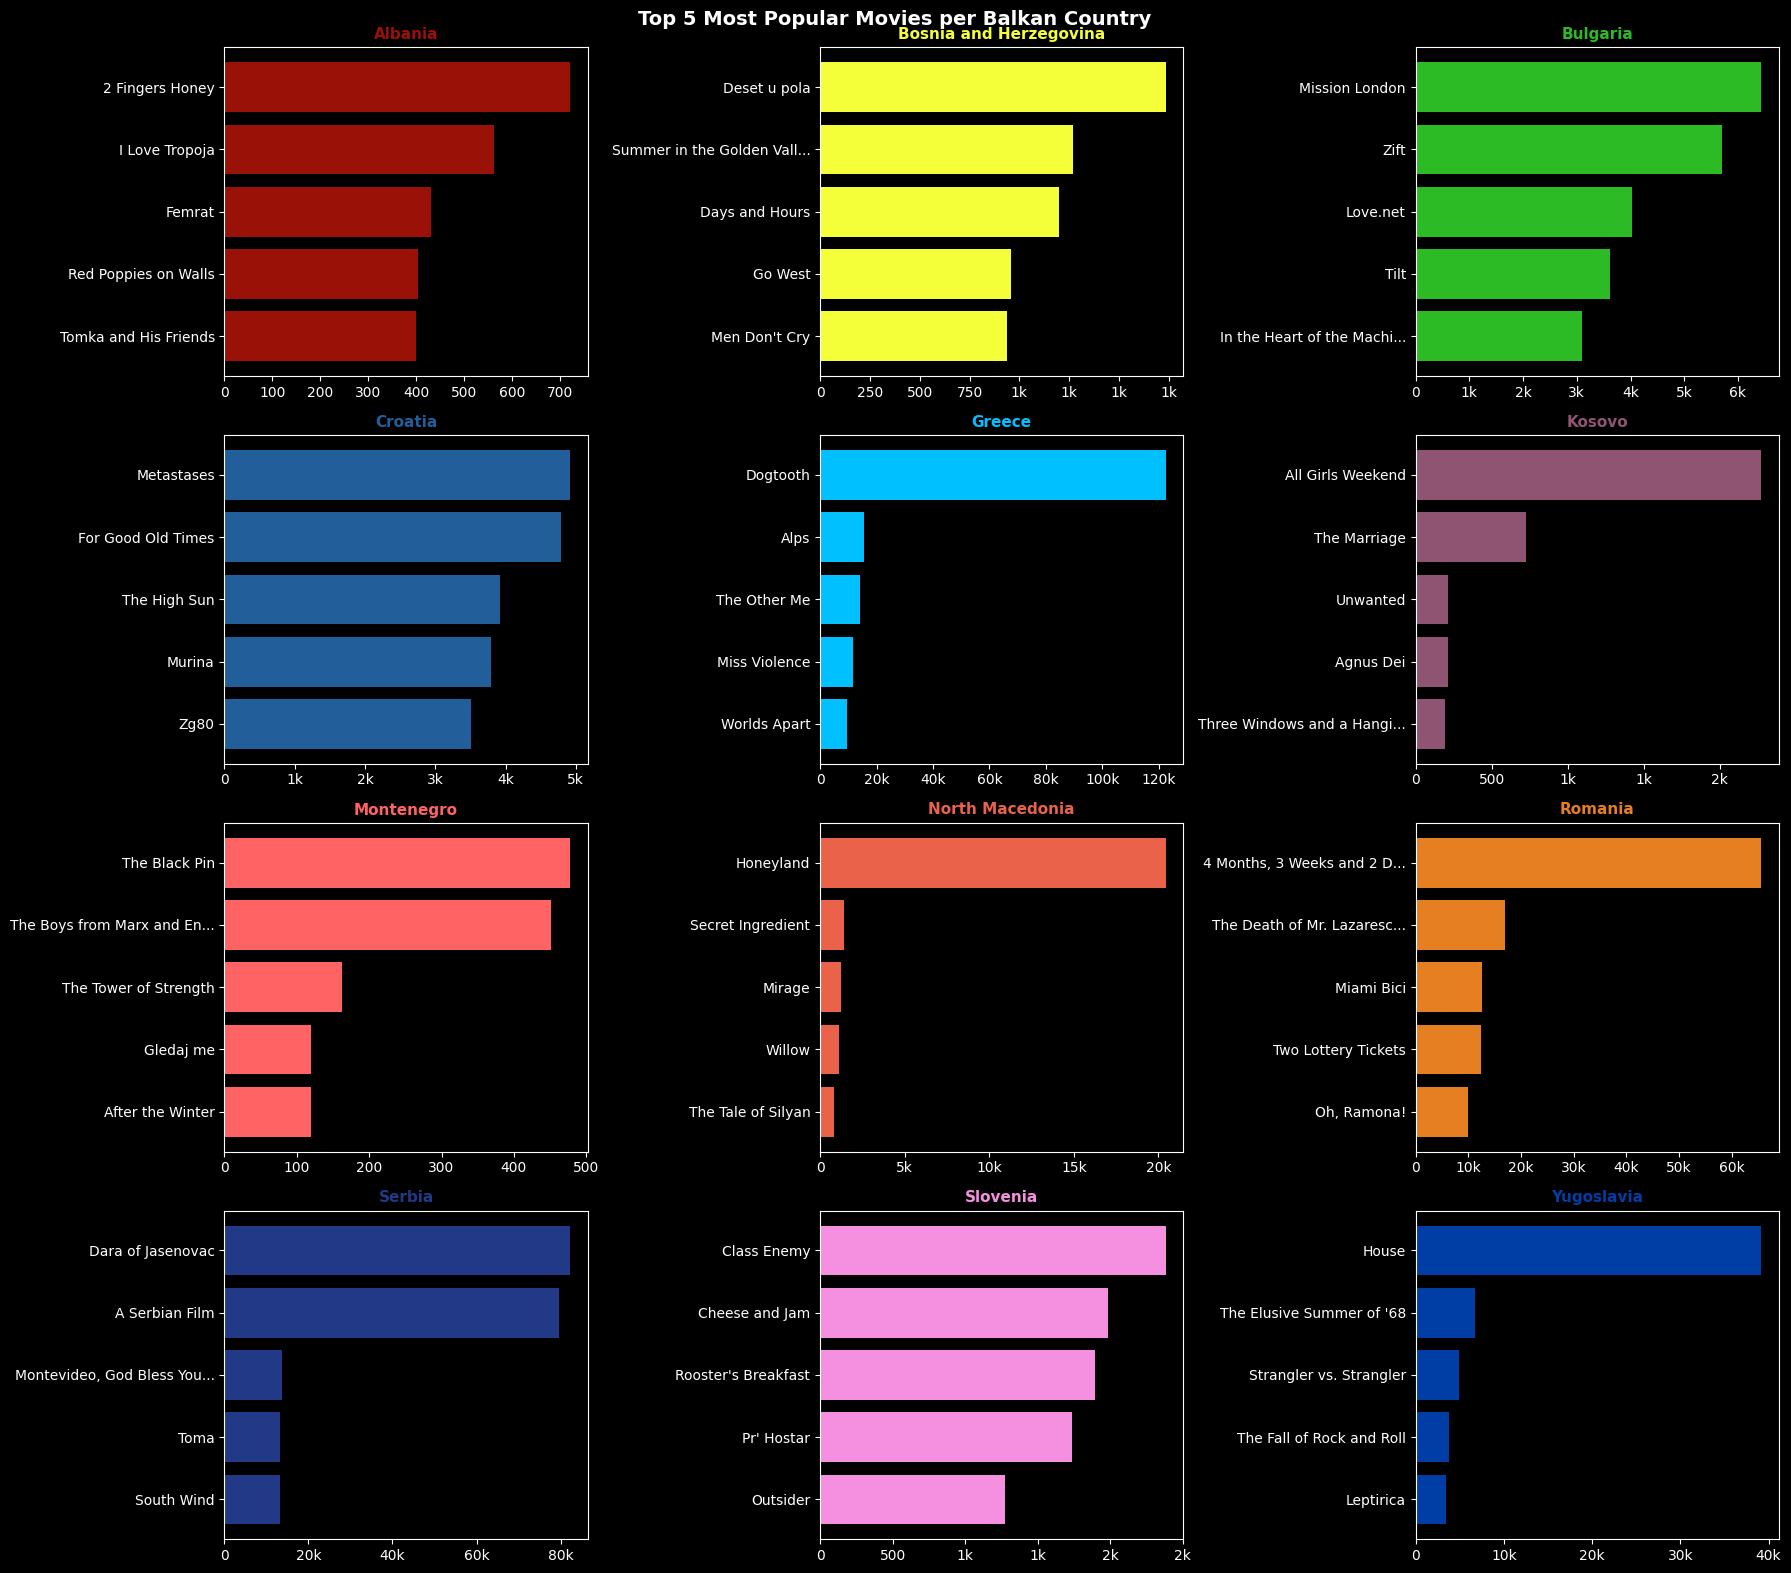

In [18]:
# Top 5 most popular movies per country
top5 = (
    movies[movies['imdb_votes'].notna()]
    .sort_values('imdb_votes', ascending=False)
    .groupby('country')
    .head(5)
    .sort_values(['country', 'imdb_votes'], ascending=[True, False])
)

countries = sorted(top5['country'].unique())
n_cols = 3
n_rows = -(-len(countries) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, country in enumerate(countries):
    ax = axes[i]
    data = top5[top5['country'] == country]
    labels = [t[:25] + '...' if len(t) > 25 else t for t in data['title_final']]
    color = COUNTRY_COLORS.get(country, 'gray')
    ax.barh(labels, data['imdb_votes'], color=color)
    ax.set_title(country, fontsize=11, fontweight='bold', color=color)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))
    ax.invert_yaxis()

for j in range(len(countries), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Top 5 Most Popular Movies per Balkan Country', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graphs/top5_popular_combined.png', dpi=150, bbox_inches='tight')
plt.show()

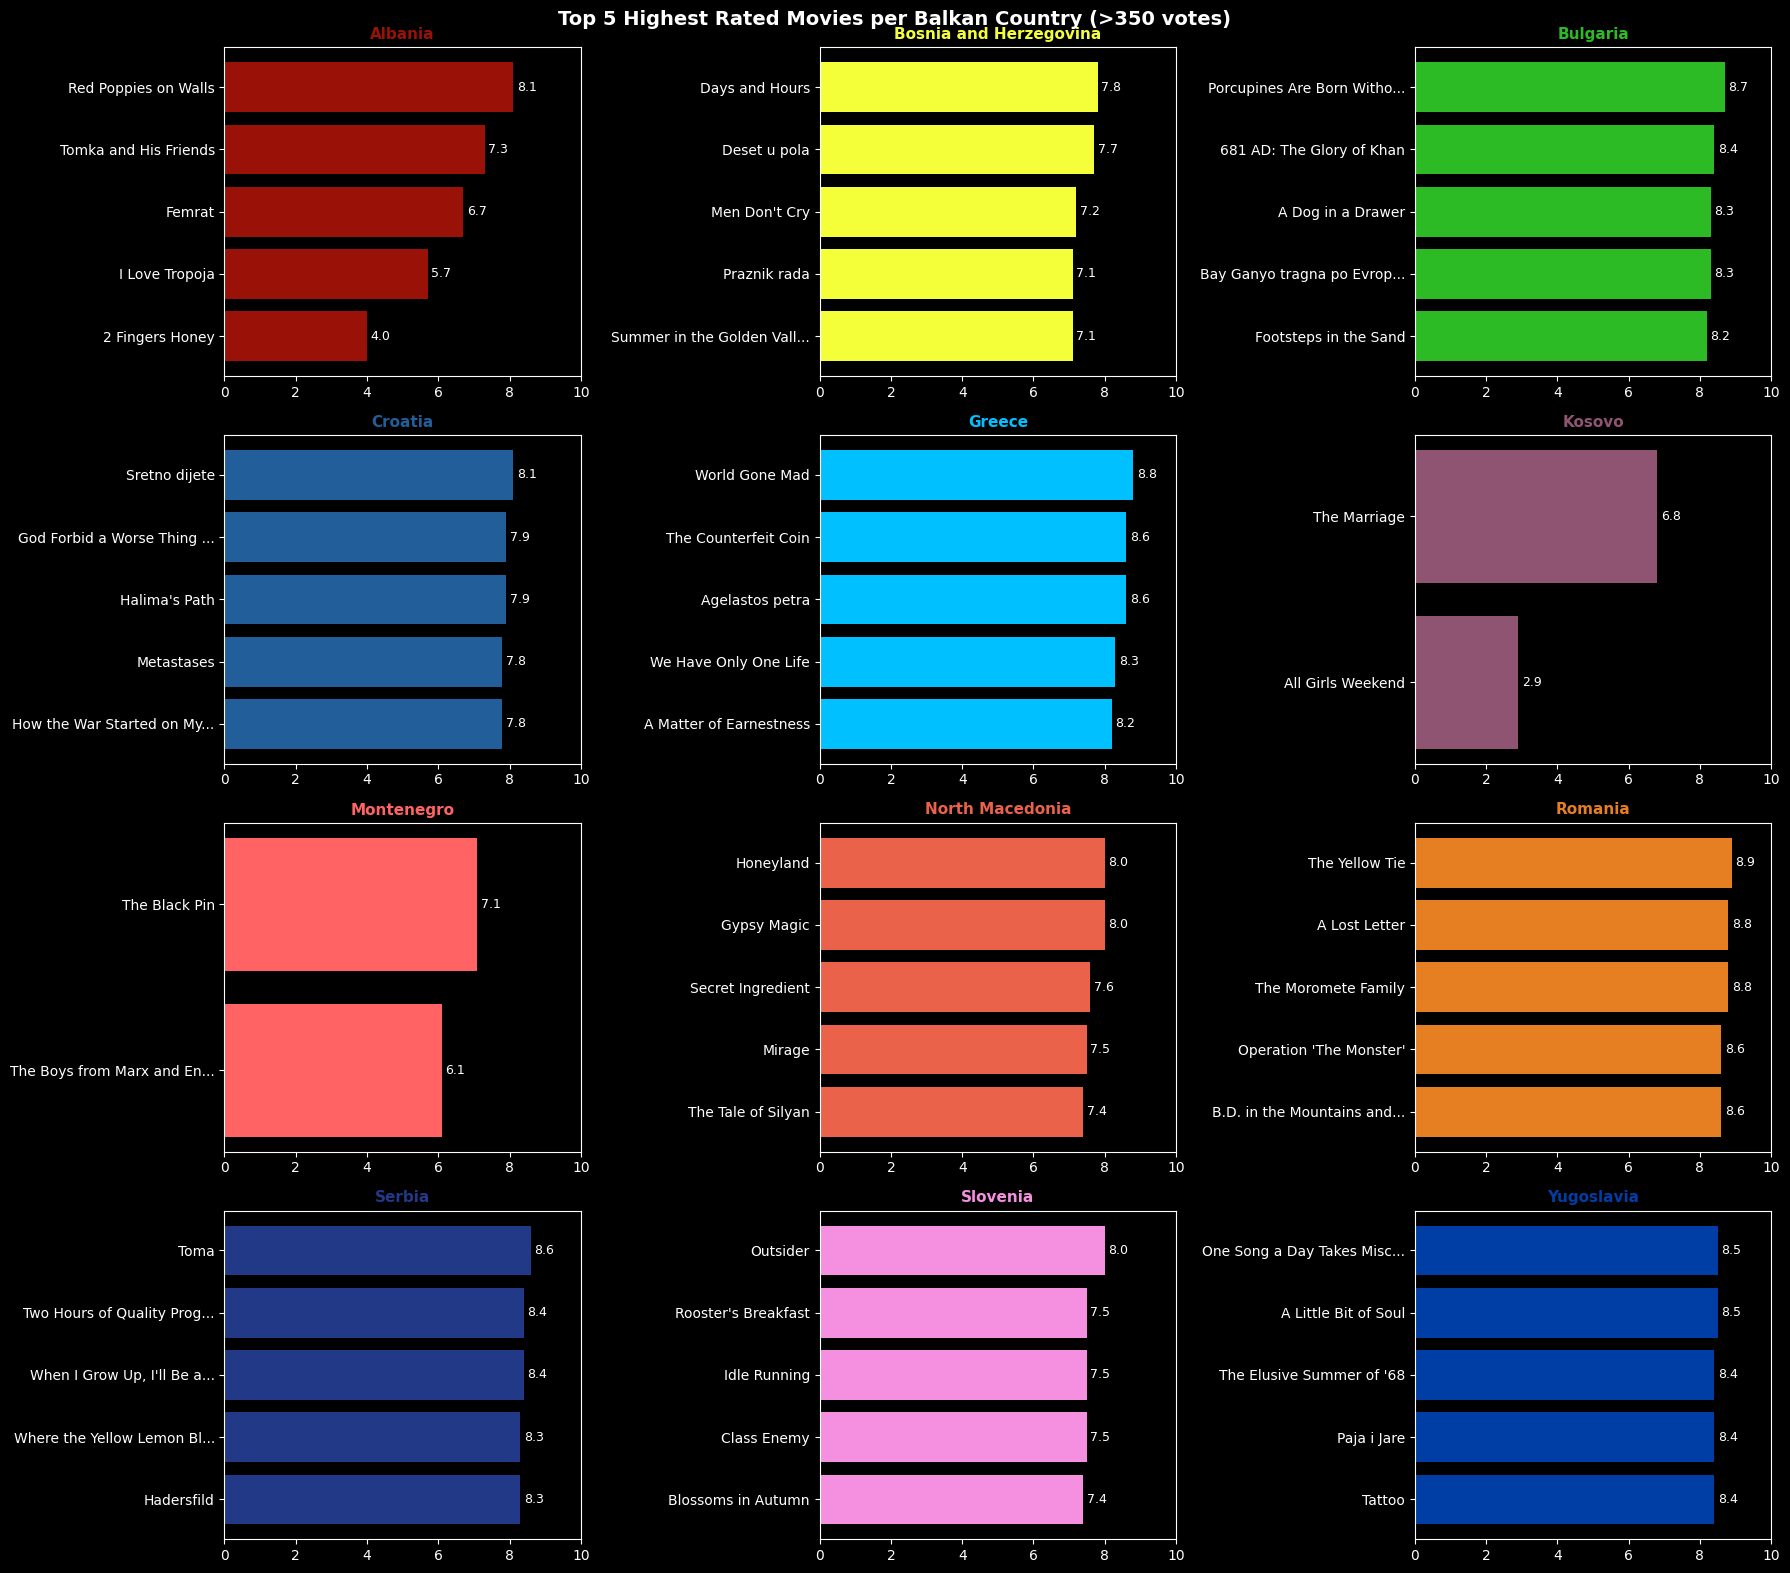

In [22]:
# Top 5 highest rated movies per country with >350 votes
top_rated = (
    movies[(movies['imdb_rating'].notna()) & (movies['imdb_votes'] >= 350)]
    .sort_values('imdb_rating', ascending=False)
    .groupby('country')
    .head(5)
    .sort_values(['country', 'imdb_rating'], ascending=[True, False])
)

countries_r = sorted(top_rated['country'].unique())
n_cols = 3
n_rows = -(-len(countries_r) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, country in enumerate(countries_r):
    ax = axes[i]
    data = top_rated[top_rated['country'] == country]
    labels = [t[:25] + '...' if len(t) > 25 else t for t in data['title_final']]
    color = COUNTRY_COLORS.get(country, 'gray')
    bars = ax.barh(labels, data['imdb_rating'], color=color)
    ax.set_xlim(0, 10)
    ax.set_title(country, fontsize=11, fontweight='bold', color=color)
    ax.invert_yaxis()
    for bar, val in zip(bars, data['imdb_rating']):
        ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val}', va='center', fontsize=9)

for j in range(len(countries_r), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Top 5 Highest Rated Movies per Balkan Country (>350 votes)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graphs/top5_rated_combined.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Export summary to CSV
summary.to_csv('data/movies_ratings_popularity_by_country.csv', index=False)